# Q-learning: glucose & reward within an episode

Train the agent as in `QLearningAgent.train`, but also record step-by-step glucose and reward for a few representative episodes, then plot those trajectories.

In [1]:
%load_ext autoreload
%autoreload 2

# allows to import modules from root directory
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from GridWorld import GridWorld, Action
from QLearningAgent import QLearningAgent

## Setup
Same parameters as the `__main__` block of `QLearningAgent.py`.

In [16]:
SEED = None

env = GridWorld(grid_size=8, glucose_target=50, glucose_max=100,
                n_food=20, max_steps=200, metabolism_rate=5, intake_amount=10,
                drive_n=2, drive_m=1, seed=SEED)
agent = QLearningAgent(n_actions=env.n_actions, alpha=0.3, gamma=0.95,
                       epsilon_start=1.0, epsilon_min=0.05, epsilon_decay=0.9,
                       seed=SEED)

N_EPISODES = 5000
# episodes whose full step-by-step trajectory we keep
RECORD_EPISODES = [0, 10, 100, 1000, N_EPISODES - 1]

## Training with trajectory logging
`run_episode` mirrors the inner loop of `train()`, but logs glucose, reward, and action at every step.

In [17]:
def run_episode(env, agent, learn=True):
    """
    Runs one episode. If learn=True, updates the Q-table (same as train()).
    Returns a dict of per-step arrays; glucose[0] is the starting glucose,
    so glucose has one more entry than reward/actions.
    """
    obs = env.reset() # reset environment
    state = agent.discretize_state(obs) # convert observation to state for q-learning
    glucose, rewards, actions = [obs["glucose_level"]], [], []
    done = False
    info = None
    while not done: # run until episode ends
        action = agent.choose_action(state)
        next_obs, reward, done, info = env.step(action) # take a step based on action
        next_state = agent.discretize_state(next_obs)
        if learn: # update Q-table if learning
            agent.update(state, action, reward, next_state)
        state = next_state

        glucose.append(next_obs["glucose_level"])
        rewards.append(reward)
        actions.append(int(action)) # we store all actions taken too
    return {
        "glucose": np.array(glucose),
        "reward": np.array(rewards),
        "cum_reward": np.cumsum(rewards), # adds all the rewards up to this step
        "actions": np.array(actions), 
        "epsilon": agent.epsilon,
        "info": info,
    }


episode_total_rewards = [] # will store total reward per episode
episode_lengths = [] # will store how long each episode is (in steps)
trajectories = {}  # episode index -> trajectory dict
for episode in range(N_EPISODES): # looping over num episodes
    traj = run_episode(env, agent, learn=True) # running a full episode
    agent.decay_epsilon() # decay epsilon after each episode
    episode_total_rewards.append(traj["reward"].sum()) # sum over all rewards
    episode_lengths.append(len(traj["reward"])) # a reward for each step; so len(reward) = total steps
    if episode in RECORD_EPISODES:
        trajectories[episode] = traj

for ep, traj in trajectories.items():
    print(f"episode {ep:>5}: {len(traj['reward']):>3} steps, "
          f"total reward {traj['reward'].sum():8.1f}, eps={traj['epsilon']:.3f}  ({traj['info']})")

episode     0:  10 steps, total reward  -2500.0, eps=1.000  (Agent starved to death.)
episode    10:  12 steps, total reward  -2500.0, eps=0.349  (Agent starved to death.)
episode   100:  14 steps, total reward  -2500.0, eps=0.050  (Agent starved to death.)
episode  1000:  20 steps, total reward  -2500.0, eps=0.050  (Agent starved to death.)
episode  4999:  36 steps, total reward  -2500.0, eps=0.050  (Agent starved to death.)


## Greedy rollout of the learned policy
Run one episode with epsilon = 0 and no Q-table updates, to see what the learned policy does on its own.

In [18]:
saved_epsilon = agent.epsilon
agent.epsilon = 0.0
greedy_traj = run_episode(env, agent, learn=False)
agent.epsilon = saved_epsilon

print(f"greedy: {len(greedy_traj['reward'])} steps, "
      f"total reward {greedy_traj['reward'].sum():.1f}  ({greedy_traj['info']})")

greedy: 34 steps, total reward -2500.0  (Agent starved to death.)


## Learning curve
Episode length (steps survived) per episode (light) and a moving average (dark); dotted lines mark the recorded episodes.

Note: total reward per episode is not a useful learning signal here. Since reward = drive(t) - drive(t+1), the per-episode sum telescopes to drive(start) - drive(end), so every episode that ends in starvation gets the same total (-2500 with these parameters).

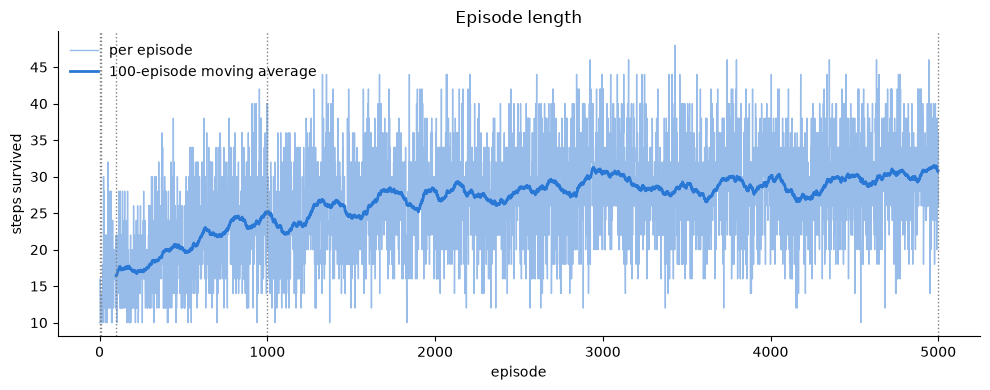

In [19]:
WINDOW = 100
lengths = np.array(episode_lengths)
# compute moving average of episode lengths
# np.ones(WINDOW) / WINDOW creates a window of size WINDOW with equal weights (here 1/100)
# so we multiply each episode length by 1/100 and sum over the window to get the average
moving_avg = np.convolve(lengths, np.ones(WINDOW) / WINDOW, mode="valid")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lengths, color="#97bcea", linewidth=1, label="per episode")
ax.plot(np.arange(WINDOW - 1, len(lengths)), moving_avg, color="#2a78d6", linewidth=2,
        label=f"{WINDOW}-episode moving average")
for ep in RECORD_EPISODES:
    ax.axvline(ep, color="gray", linestyle=":", linewidth=1) # gray lines are recorded episodes
ax.set_xlabel("episode")
ax.set_ylabel("steps survived")
ax.set_title("Episode length")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Glucose and reward over representative episodes
One column per episode. Rows: glucose (dashed line = target), per-step reward, cumulative reward. Rows share a y-axis so episodes are directly comparable. Orange ticks on the glucose plot mark steps where the agent chose EAT.

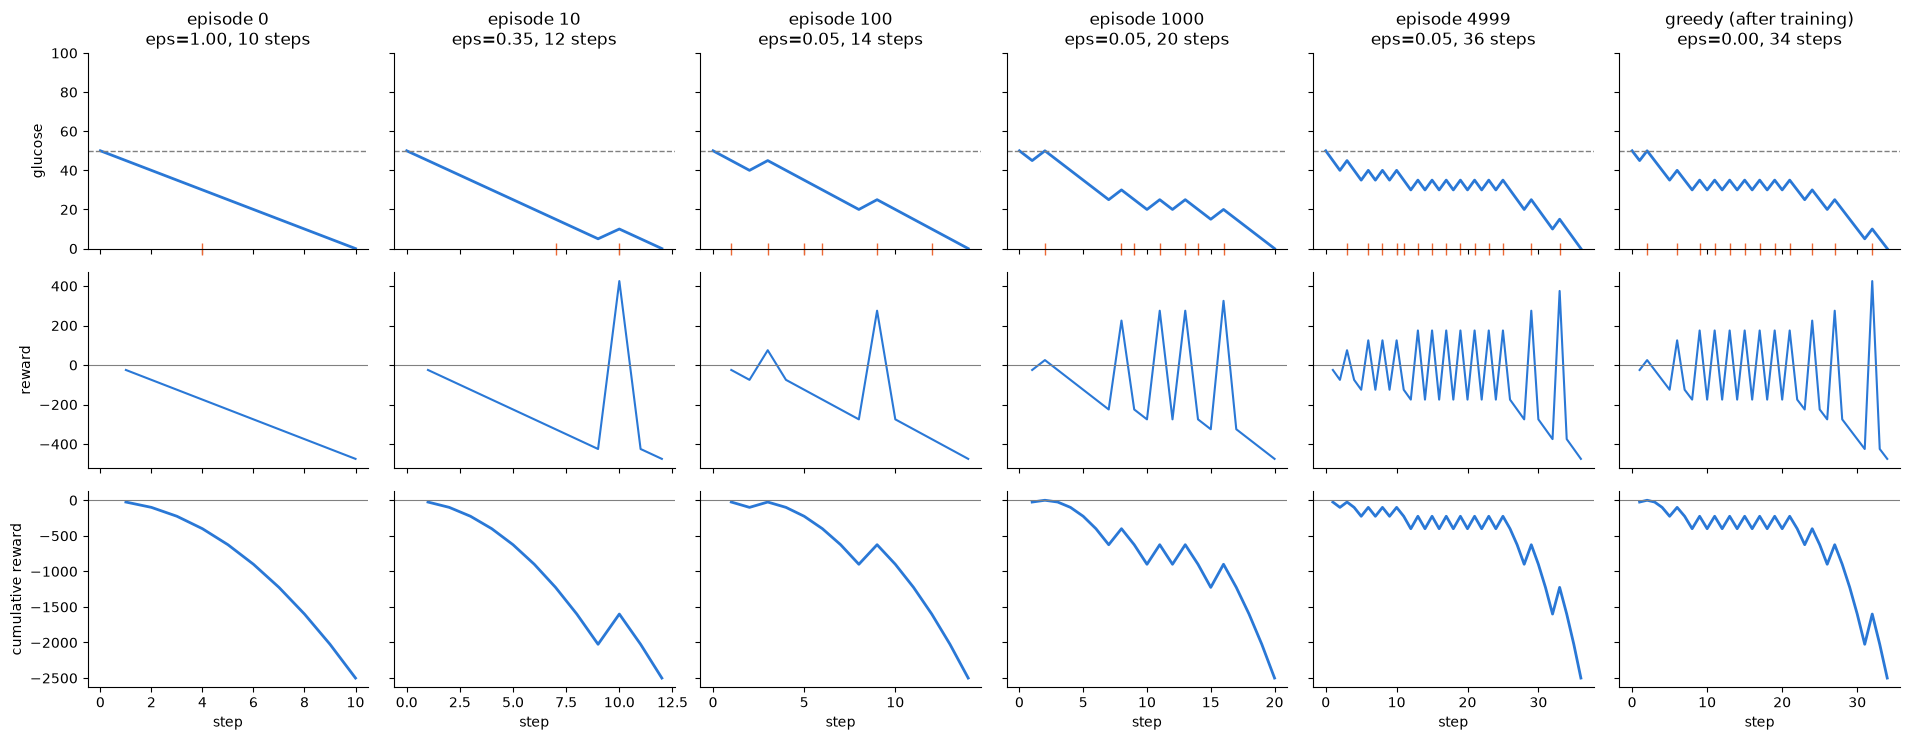

In [20]:
def plot_trajectories(trajs, env, titles=None, color="#2a78d6", eat_color="#eb6834"):
    """
    trajs: dict of {label: trajectory dict from run_episode}
    """
    labels = list(trajs.keys())
    n = len(labels)
    fig, axes = plt.subplots(3, n, figsize=(3.2 * n, 7.5), sharex="col", sharey="row",
                             squeeze=False)

    for col, label in enumerate(labels):
        traj = trajs[label]
        steps = np.arange(1, len(traj["reward"]) + 1)

        # glucose (index 0 = start of episode, before any step)
        ax = axes[0, col]
        ax.plot(np.arange(len(traj["glucose"])), traj["glucose"], color=color, linewidth=2)
        ax.axhline(env.glucose_target, color="gray", linestyle="--", linewidth=1)
        eat_steps = steps[traj["actions"] == Action.EAT]
        ax.plot(eat_steps, np.zeros_like(eat_steps), "|", color=eat_color, markersize=8,
                clip_on=False)
        ax.set_ylim(0, env.glucose_max)
        ax.set_title(titles[col] if titles else str(label))

        # per-step reward
        ax = axes[1, col]
        ax.plot(steps, traj["reward"], color=color, linewidth=1.5)
        ax.axhline(0, color="gray", linewidth=0.8)

        # cumulative reward
        ax = axes[2, col]
        ax.plot(steps, traj["cum_reward"], color=color, linewidth=2)
        ax.axhline(0, color="gray", linewidth=0.8)
        ax.set_xlabel("step")

    axes[0, 0].set_ylabel("glucose")
    axes[1, 0].set_ylabel("reward")
    axes[2, 0].set_ylabel("cumulative reward")
    for ax in axes.flat:
        ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


plot_trajs = {f"episode {ep}": trajectories[ep] for ep in RECORD_EPISODES}
plot_trajs["greedy (after training)"] = greedy_traj
titles = [f"{k}\neps={v['epsilon']:.2f}, {len(v['reward'])} steps" for k, v in plot_trajs.items()]
plot_trajectories(plot_trajs, env, titles=titles)